# SD signal breakdown vs UMD, with and without the reconstruction requirement

The last figure of `Scripts/plots_seccion_6.ipynb`, rebuilt from the v13 reprocessing, plus
what that figure could not show: the SD MC curves over **every simulated SD station**, not
only those with a reconstructed station object.

| Curve | Comes from | Can it be drawn without requiring a reconstructed SD station? |
|---|---|---|
| UMD (`nMuones_MC`) | `modulos/` | **No.** No reconstructed tank ⇒ Offline writes no UMD modules. |
| SD Electromagnetic (`sd_nEM_MC`) | `estaciones_sd/` | **Yes** — drawn both ways |
| SD Muonic (`sd_nMuons_MC`) | `estaciones_sd/` | **Yes** — drawn both ways |
| SD Total Signal (`sdSignal_REC`, VEM) | `estaciones_sd/` | **No.** It is itself a reconstructed signal. |

The fit is the one from your cell: 12 φ bins, mean and SEM per bin, normalise by the mean of
the 12 means, fit `1 + A1·cos φ` with `curve_fit` (bounds ±2), drop the band if the error
exceeds 0.5, require ≥ 15 rows and ≥ 5 usable bins. **A1 > 0 = early excess.**

Structure of the notebook: **1** settings · **2** load · **3** fit one band · **4** fit a whole
curve · **5** declare which curves to draw · **6** compute them · **7** cross-check · **8** plot.

In [1]:
# ============================== 1. SETTINGS ==============================
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

try:                       # so the file also runs as a plain script
    display
except NameError:
    def display(objeto):
        print(objeto.to_string() if hasattr(objeto, "to_string") else objeto)

CARPETA_NOTEBOOK = Path(os.path.abspath(""))
CARPETA_RESULTADOS = CARPETA_NOTEBOOK / "resultados"
CARPETA_RESULTADOS.mkdir(exist_ok=True)

DATOS_V13 = Path("/home/lsilva/Github/ADST_Alexey_module_v13/parquet_sib_proton_17")

THETA_MIN = 30          # degrees
THETA_MAX = 40
BORDES_R = np.array([150, 300, 450, 600, 750, 900, 1050, 1200, 1350])   # metres
CENTROS_R = 0.5 * (BORDES_R[1:] + BORDES_R[:-1])
BORDES_PHI = np.linspace(-180, 180, 13)                                  # 12 bins of 30 deg
CENTROS_PHI = 0.5 * (BORDES_PHI[1:] + BORDES_PHI[:-1])

MIN_FILAS_POR_BANDA = 15
MIN_BINS_VALIDOS = 5
MAX_ERROR_ACEPTADO = 0.5

COLOR_PROTON = "royalblue"

# A station occurrence is unique only as (file, shower, station): the same shower id appears
# in several ROOT files, so joining on (event_id, sdId) alone would be a many-to-many merge.
CLAVE_ESTACION = ["source", "event_id", "sdId"]

## 2. Load the two tables

`phi_plane_euler_MC_true_core` is stored in radians in [0, 2π) **with** the historical +π.
`a_phi_temprano_tardio` undoes it and wraps to [-180°, 180°), exactly as `plots_seccion_6` does.

In [2]:
def a_grados(serie):
    """Pasa radianes a grados si es necesario (same helper as plots_seccion_6)."""
    if serie.dropna().abs().max() < 7.0:
        return np.rad2deg(serie)
    return serie


def a_phi_temprano_tardio(serie_phi):
    """Undo the historical +180 and wrap to [-180, 180). 0 = early, ±180 = late."""
    grados = a_grados(serie_phi)
    sin_el_mas_180 = (grados - 180) % 360
    return (sin_el_mas_180 + 180) % 360 - 180


def leer_carpeta(carpeta, columnas):
    """Read every parquet of a folder into one DataFrame, adding `source` = ROOT file name."""
    partes = []
    for archivo in sorted(Path(carpeta).glob("*.parquet")):
        parte = pd.read_parquet(archivo, columns=columnas)
        parte["source"] = archivo.with_suffix(".root").name
        partes.append(parte)
    if not partes:
        raise FileNotFoundError(f"No hay parquet en {carpeta}")
    return pd.concat(partes, ignore_index=True)


def cargar_umd():
    """UMD modules: Infill counters, zenith band, with the reconstruction requirement."""
    tabla = leer_carpeta(DATOS_V13 / "modulos",
                         ["event_id", "counterId", "sdId", "theta_MC", "r_core_MC",
                          "phi_plane_euler_MC_true_core", "nMuones_MC", "has_sd_rec"])
    es_infill = tabla["counterId"] >= 100000
    en_banda_cenital = tabla["theta_MC"].between(THETA_MIN, THETA_MAX, inclusive="left")
    tabla = tabla[es_infill & en_banda_cenital & tabla["has_sd_rec"]].copy()
    tabla["phi_deg"] = a_phi_temprano_tardio(tabla["phi_plane_euler_MC_true_core"])
    tabla["radio"] = tabla["r_core_MC"]
    return tabla


def cargar_estaciones_sd():
    """Every simulated SD station in the zenith band: physical Infill ids, reconstructed or not."""
    tabla = leer_carpeta(DATOS_V13 / "estaciones_sd",
                         ["event_id", "sdId", "theta_MC", "r_core_MC",
                          "phi_plane_euler_MC_true_core", "sd_nMuons_MC", "sd_nEM_MC",
                          "sdSignal_REC", "has_sd_rec"])
    es_sd_fisica = (tabla["sdId"] > 2000) & (tabla["sdId"] < 90000)
    en_banda_cenital = tabla["theta_MC"].between(THETA_MIN, THETA_MAX, inclusive="left")
    tabla = tabla[es_sd_fisica & en_banda_cenital].copy()
    tabla["phi_deg"] = a_phi_temprano_tardio(tabla["phi_plane_euler_MC_true_core"])
    tabla["radio"] = tabla["r_core_MC"]
    return tabla


umd = cargar_umd()
estaciones_sd = cargar_estaciones_sd()
estaciones_sd_reconstruidas = estaciones_sd[estaciones_sd["has_sd_rec"]]

print(f"UMD                        : {len(umd):>9,} módulos")
print(f"Estaciones SD (todas)      : {len(estaciones_sd):>9,}")
print(f"Estaciones SD con SD REC   : {len(estaciones_sd_reconstruidas):>9,}")
print(f"Estaciones SD sin SD REC   : {len(estaciones_sd) - len(estaciones_sd_reconstruidas):>9,}")

UMD                        :   156,633 módulos
Estaciones SD (todas)      : 1,045,964
Estaciones SD con SD REC   :    52,211
Estaciones SD sin SD REC   :   993,753


## 3. Fit one radial band

Returns a **dict with named fields**, so nothing has to be remembered by position.
`A1` and `error` are NaN when the band does not meet the quality rules; the other fields
still say why.

In [3]:
def modelo_armonico(phi_deg, A1):
    return 1.0 + A1 * np.cos(np.deg2rad(phi_deg))


def ajustar_una_banda(tabla, columna, r_min, r_max):
    """Fit A1 in one radial band. Same procedure as plots_seccion_6."""
    resultado = {"r_min": r_min, "r_max": r_max, "r_centro": 0.5 * (r_min + r_max),
                 "A1": np.nan, "error": np.nan, "n_filas": 0, "n_bins_validos": 0,
                 "motivo": ""}

    en_la_banda = (tabla["radio"] >= r_min) & (tabla["radio"] < r_max)
    banda = tabla[en_la_banda].dropna(subset=[columna])
    resultado["n_filas"] = len(banda)
    if len(banda) < MIN_FILAS_POR_BANDA:
        resultado["motivo"] = "pocas filas"
        return resultado

    # Mean and standard error of the mean in each of the 12 azimuth bins.
    bin_de_phi = pd.cut(banda["phi_deg"], bins=BORDES_PHI)
    por_bin = banda.groupby(bin_de_phi, observed=False)[columna].agg(["mean", "sem"])
    medias = por_bin["mean"].to_numpy()
    errores = por_bin["sem"].to_numpy()

    # Normalise by the average of the 12 means, so the fitted model has no free offset.
    normalizacion = np.nanmean(medias)
    if not np.isfinite(normalizacion) or normalizacion <= 0:
        resultado["motivo"] = "normalización no positiva"
        return resultado
    y = medias / normalizacion
    error_y = errores / normalizacion

    bin_utilizable = np.isfinite(y) & np.isfinite(error_y) & (error_y > 0)
    resultado["n_bins_validos"] = int(bin_utilizable.sum())
    if resultado["n_bins_validos"] < MIN_BINS_VALIDOS:
        resultado["motivo"] = "pocos bins válidos"
        return resultado

    try:
        parametros, covarianza = curve_fit(
            modelo_armonico, CENTROS_PHI[bin_utilizable], y[bin_utilizable],
            sigma=error_y[bin_utilizable], absolute_sigma=True, bounds=(-2.0, 2.0))
    except RuntimeError:
        resultado["motivo"] = "el ajuste no convergió"
        return resultado

    A1 = parametros[0]
    error_A1 = np.sqrt(np.diag(covarianza))[0]
    if error_A1 > MAX_ERROR_ACEPTADO:
        resultado["motivo"] = "error demasiado grande"
        return resultado

    resultado["A1"] = A1
    resultado["error"] = error_A1
    resultado["motivo"] = "ok"
    return resultado

## 4. Fit a whole curve

One row per radial band, as a `DataFrame` with named columns.

In [4]:
def calcular_curva(tabla, columna):
    """Fit every radial band. Returns a DataFrame: r_min, r_max, r_centro, A1, error, ..."""
    filas = []
    for r_min, r_max in zip(BORDES_R[:-1], BORDES_R[1:]):
        filas.append(ajustar_una_banda(tabla, columna, r_min, r_max))
    return pd.DataFrame(filas)

## 5. Which curves go on the plot

One `Curva` per line, with every field named. `requiere_rec` drives both the sample used and
the drawing style (dashed + hollow markers), so the two can never disagree.

In [5]:
@dataclass
class Curva:
    clave: str            # short id, used for the results dictionary
    etiqueta: str         # legend text
    tabla: str            # which table: "umd" or "sd"
    columna: str          # which column is averaged
    color: str
    marcador: str
    eje: str              # "izquierdo" (counts) or "derecho" (VEM)
    requiere_rec: bool    # does this curve require a reconstructed SD station?


CURVAS = [
    Curva(clave="umd",
          etiqueta="UMD (requiere SD REC)",
          tabla="umd", columna="nMuones_MC",
          color="mediumblue", marcador="s", eje="izquierdo", requiere_rec=True),
    Curva(clave="em_mc",
          etiqueta="SD Electromagnetic — sólo MC",
          tabla="sd", columna="sd_nEM_MC",
          color="darkorange", marcador="^", eje="izquierdo", requiere_rec=False),
    Curva(clave="em_rec",
          etiqueta="SD Electromagnetic — con SD REC",
          tabla="sd", columna="sd_nEM_MC",
          color="darkorange", marcador="^", eje="izquierdo", requiere_rec=True),
    Curva(clave="muones_mc",
          etiqueta="SD Muonic — sólo MC",
          tabla="sd", columna="sd_nMuons_MC",
          color="forestgreen", marcador="v", eje="izquierdo", requiere_rec=False),
    Curva(clave="muones_rec",
          etiqueta="SD Muonic — con SD REC",
          tabla="sd", columna="sd_nMuons_MC",
          color="forestgreen", marcador="v", eje="izquierdo", requiere_rec=True),
    Curva(clave="senal_total",
          etiqueta="SD Total Signal (VEM, sólo REC)",
          tabla="sd", columna="sdSignal_REC",
          color="firebrick", marcador="o", eje="derecho", requiere_rec=True),
]


def elegir_tabla(curva):
    """The sample a curve is computed on. The UMD table is always reconstruction-selected."""
    if curva.tabla == "umd":
        return umd
    if curva.requiere_rec:
        return estaciones_sd_reconstruidas
    return estaciones_sd

## 6. Compute every curve

In [6]:
resultados_por_curva = {}
for curva in CURVAS:
    resultados_por_curva[curva.clave] = calcular_curva(elegir_tabla(curva), curva.columna)
    print(f"{curva.etiqueta:<35} listo ({len(elegir_tabla(curva)):,} filas)")

# One tidy table with everything, saved next to the figure.
filas_tidy = []
for curva in CURVAS:
    tabla_curva = resultados_por_curva[curva.clave].copy()
    tabla_curva.insert(0, "curva", curva.etiqueta)
    filas_tidy.append(tabla_curva)
resultados_tidy = pd.concat(filas_tidy, ignore_index=True)
resultados_tidy.to_csv(CARPETA_RESULTADOS / "desglose_sd_mc_vs_rec_detalle.csv", index=False)

# The same numbers as a compact A1 table, one column per curve.
tabla_A1 = pd.DataFrame(index=[f"{lo}-{hi}" for lo, hi in zip(BORDES_R[:-1], BORDES_R[1:])])
tabla_A1.index.name = "r [m]"
for curva in CURVAS:
    tabla_A1[curva.etiqueta] = resultados_por_curva[curva.clave]["A1"].to_numpy()
tabla_A1.to_csv(CARPETA_RESULTADOS / "desglose_sd_mc_vs_rec.csv")
display(tabla_A1.round(4))

UMD (requiere SD REC)               listo (156,633 filas)


SD Electromagnetic — sólo MC        listo (1,045,964 filas)


SD Electromagnetic — con SD REC     listo (52,211 filas)


SD Muonic — sólo MC                 listo (1,045,964 filas)


SD Muonic — con SD REC              listo (52,211 filas)


SD Total Signal (VEM, sólo REC)     listo (52,211 filas)


,UMD (requiere SD REC),SD Electromagnetic — sólo MC,SD Electromagnetic — con SD REC,SD Muonic — sólo MC,SD Muonic — con SD REC,"SD Total Signal (VEM, sólo REC)"
r [m],,,,,,
150-300,0.0620,0.2816,0.2816,0.0331,0.0331,0.0742
300-450,0.0933,0.3799,0.3799,0.0602,0.0602,0.1098
450-600,0.0853,0.4133,0.4133,0.0588,0.0588,0.1103
600-750,0.1147,0.4615,0.4607,0.0605,0.0593,0.1306
750-900,0.1148,0.4631,0.4483,0.0576,0.0402,0.0971
900-1050,0.0941,0.4931,0.4474,0.0660,-0.0158,0.0536
1050-1200,0.1057,0.5110,0.4437,0.0683,-0.0641,-0.0165
1200-1350,0.0816,0.5183,0.4479,0.0689,-0.1240,-0.0979


## 7. Cross-check: one row per station vs one row per module

`plots_seccion_6` computes the SD curves on the **module** table, where each station appears
once per module (3 times here). That repetition leaves the bin means alone, so **A1 does not
change**, but it triples the number of entries per bin and therefore shrinks the SEM by about
√3 — the SD error bars of the published figure are optimistic by that factor, because the
copies are not independent measurements. Here every SD curve uses one row per station.

In [7]:
def construir_sd_por_modulo():
    """The REC-selected SD sample as plots_seccion_6 builds it: one row per UMD module."""
    columnas = ["event_id", "counterId", "sdId", "theta_MC", "r_core_MC",
                "phi_plane_euler_MC_true_core", "has_sd_rec"]
    modulos = leer_carpeta(DATOS_V13 / "modulos", columnas)
    es_infill = modulos["counterId"] >= 100000
    en_banda_cenital = modulos["theta_MC"].between(THETA_MIN, THETA_MAX, inclusive="left")
    modulos = modulos[es_infill & en_banda_cenital & modulos["has_sd_rec"]].copy()
    modulos["phi_deg"] = a_phi_temprano_tardio(modulos["phi_plane_euler_MC_true_core"])
    modulos["radio"] = modulos["r_core_MC"]
    conteos_sd = estaciones_sd[CLAVE_ESTACION + ["sd_nMuons_MC"]]
    return modulos.merge(conteos_sd, on=CLAVE_ESTACION, how="left", validate="many_to_one")


por_estacion = calcular_curva(estaciones_sd_reconstruidas, "sd_nMuons_MC")
por_modulo = calcular_curva(construir_sd_por_modulo(), "sd_nMuons_MC")

diferencia_A1 = np.nanmax(np.abs(por_estacion["A1"] - por_modulo["A1"]))
cociente_errores = np.nanmean(por_modulo["error"] / por_estacion["error"])
print(f"A1, por estación vs por módulo : máxima diferencia = {diferencia_A1:.1e}")
print(f"Errores, por módulo / por estación: {cociente_errores:.3f}  (esperado 1/sqrt(3) = 0.577)")

A1, por estación vs por módulo : máxima diferencia = 1.8e-05
Errores, por módulo / por estación: 0.577  (esperado 1/sqrt(3) = 0.577)


## 8. The figure

Solid + filled marker = the whole simulated array. Dashed + hollow marker = requiring a
reconstructed SD station. Same axes, limits and annotations as `plots_seccion_6`.

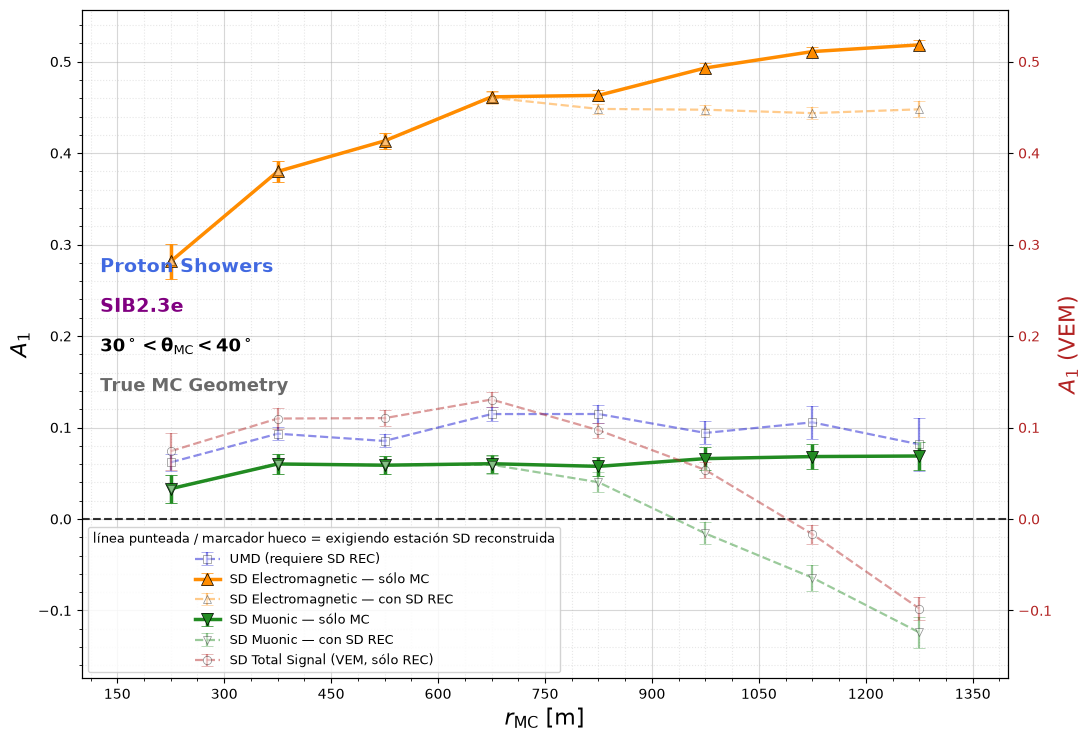

In [8]:
def estilo_de_linea(curva):
    """Drawing style. Dashed and faded when the curve requires a reconstructed station."""
    if curva.requiere_rec:
        return {"linestyle": "--", "linewidth": 1.6, "alpha": 0.45,
                "markersize": 6, "markerfacecolor": "white"}
    return {"linestyle": "-", "linewidth": 2.5, "alpha": 1.0,
            "markersize": 8, "markerfacecolor": curva.color}


figura, eje_conteos = plt.subplots(figsize=(11, 7.5))
eje_vem = eje_conteos.twinx()

lineas_dibujadas = []
etiquetas = []
for curva in CURVAS:
    resultado = resultados_por_curva[curva.clave]
    eje = eje_vem if curva.eje == "derecho" else eje_conteos
    estilo = estilo_de_linea(curva)
    linea = eje.errorbar(resultado["r_centro"], resultado["A1"], yerr=resultado["error"],
                         marker=curva.marcador, color=curva.color, capsize=4,
                         markeredgecolor="black", markeredgewidth=0.5, **estilo)
    lineas_dibujadas.append(linea)
    etiquetas.append(curva.etiqueta)

eje_conteos.axhline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
eje_conteos.set_xlabel(r"$r_{\mathrm{MC}}$ [m]", fontsize=16)
eje_conteos.set_ylabel(r"$A_1$", fontsize=16)
eje_vem.set_ylabel(r"$A_1$ (VEM)", fontsize=16, color="firebrick")
eje_vem.tick_params(axis="y", labelcolor="firebrick")
eje_conteos.set_xlim(100, 1400)
eje_conteos.set_xticks(BORDES_R)

# Both vertical axes must share limits, or the two scales would be misleading.
limite_inferior = min(eje_conteos.get_ylim()[0], eje_vem.get_ylim()[0], -0.15)
limite_superior = max(eje_conteos.get_ylim()[1], eje_vem.get_ylim()[1], 0.25)
eje_conteos.set_ylim(limite_inferior, limite_superior)
eje_vem.set_ylim(limite_inferior, limite_superior)

eje_conteos.grid(True, which="major", linestyle="-", alpha=0.5)
eje_conteos.grid(True, which="minor", linestyle=":", alpha=0.3)
eje_conteos.minorticks_on()
eje_conteos.legend(lineas_dibujadas, etiquetas, fontsize=9, loc="lower left", framealpha=0.85,
                   title="línea punteada / marcador hueco = exigiendo estación SD reconstruida",
                   title_fontsize=9)

# Annotations go on the empty middle-left band: the top right is taken by the EM curve.
anotaciones = [
    (0.63, r"$\mathbf{Proton\ Showers}$", 14, COLOR_PROTON),
    (0.57, r"$\mathbf{SIB2.3e}$", 14, "purple"),
    (0.51, rf"$\mathbf{{{THETA_MIN}^\circ < \theta_{{\mathrm{{MC}}}} < {THETA_MAX}^\circ}}$", 13, "black"),
    (0.45, r"$\mathbf{True\ MC\ Geometry}$", 13, "dimgray"),
]
for altura, texto, tamano, color in anotaciones:
    eje_conteos.text(0.02, altura, texto, transform=eje_conteos.transAxes,
                     fontsize=tamano, va="top", ha="left", color=color)

plt.tight_layout()
plt.savefig(CARPETA_RESULTADOS / "SD_Desglose_MC_vs_REC_TwinAxes.pdf", dpi=300)
plt.savefig(CARPETA_RESULTADOS / "SD_Desglose_MC_vs_REC_TwinAxes.png", dpi=170)
plt.show()

## How to read it

- **Green, dashed vs solid:** the dashed curve is the one in your thesis figure, diving negative
  at large r. The solid one, over the whole simulated array, does not. The only difference
  between them is the reconstruction requirement: same showers, same geometry, same MC counts.
- **Orange (EM):** also shown both ways. It is affected by the requirement at large r, but stays
  strongly positive either way, as expected for a component tied to atmospheric attenuation.
- **Red (total VEM, right axis):** reconstruction-only by construction; an unreconstructed
  station has no reconstructed signal.
- **Blue (UMD):** also reconstruction-selected, unavoidably. No unselected UMD curve can be built
  from these ADSTs, so this figure does not show one.